# PyTorch and Albumentations for semantic segmentation

This example shows how to use Albumentations for binary semantic segmentation. We will use the [The Oxford-IIIT Pet Dataset
](https://www.robots.ox.ac.uk/~vgg/data/pets/). The task will be to classify each pixel of an input image either as `pet` or `background`.

### Install the required libraries

We will use [TernausNet](https://github.com/ternaus/TernausNet), a library that provides pretrained [UNet](https://en.wikipedia.org/wiki/U-Net) models for the semantic segmentation task.

In [ ]:
!pip install ternausnet > /dev/null

### Import the required libraries

In [ ]:
import copy
import os
import random
import shutil
from collections import defaultdict
from urllib.request import urlretrieve

import albumentations as A
import albumentations.augmentations.functional as F
import cv2
import matplotlib.pyplot as plt
import numpy as np
import ternausnet.models
import torch
import torch.optim
from albumentations.pytorch import ToTensorV2
from torch import nn
from torch.backends import cudnn
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

cudnn.benchmark = True

### Define functions to download an archived dataset and unpack it

In [ ]:
class TqdmUpTo(tqdm):
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize is not None:
            self.total = tsize
        self.update(b * bsize - self.n)


def download_url(url, filepath):
    directory = os.path.dirname(os.path.abspath(filepath))
    os.makedirs(directory, exist_ok=True)
    if os.path.exists(filepath):
        print("Dataset already exists on the disk. Skipping download.")
        return

    with TqdmUpTo(unit="B", unit_scale=True, unit_divisor=1024, miniters=1, desc=os.path.basename(filepath)) as t:
        urlretrieve(url, filename=filepath, reporthook=t.update_to, data=None)
        t.total = t.n


def extract_archive(filepath):
    extract_dir = os.path.dirname(os.path.abspath(filepath))
    shutil.unpack_archive(filepath, extract_dir)

### Set the root directory for the downloaded dataset

In [ ]:
dataset_directory = os.path.join(os.environ["HOME"], "datasets/oxford-iiit-pet")

### Download and extract the `Cats vs. Dogs` dataset

In [ ]:
filepath = os.path.join(dataset_directory, "images.tar.gz")
download_url(
    url="https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz",
    filepath=filepath,
)
extract_archive(filepath)

Dataset already exists on the disk. Skipping download.


In [ ]:
filepath = os.path.join(dataset_directory, "annotations.tar.gz")
download_url(
    url="https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz",
    filepath=filepath,
)
extract_archive(filepath)

Dataset already exists on the disk. Skipping download.


### Split files from the dataset into the train and validation sets

Some files in the dataset are broken, so we will use only those image files that OpenCV could load correctly. We will use 6000 images for training, 1374 images for validation, and 10 images for testing.

In [ ]:
root_directory = os.path.join(dataset_directory)
images_directory = os.path.join(root_directory, "images")
masks_directory = os.path.join(root_directory, "annotations", "trimaps")

images_filenames = sorted(os.listdir(images_directory))
correct_images_filenames = [i for i in images_filenames if cv2.imread(os.path.join(images_directory, i)) is not None]

random.seed(42)
random.shuffle(correct_images_filenames)

train_images_filenames = correct_images_filenames[:6000]
val_images_filenames = correct_images_filenames[6000:-10]
test_images_filenames = images_filenames[-10:]

print(len(train_images_filenames), len(val_images_filenames), len(test_images_filenames))

6000 1374 10


### Define a function to preprocess a mask

The dataset contains pixel-level trimap segmentation. For each image, there is an associated PNG file with a mask. The size of a mask equals to the size of the related image. Each pixel in a mask image can take one of three values: `1`, `2`, or `3`. `1` means that this pixel of an image belongs to the class `pet`, `2` - to the class `background`, `3` - to the class `border`. Since this example demonstrates a task of binary segmentation (that is assigning one of two classes to each pixel), we will preprocess the mask, so it will contain only two uniques values: `0.0` if a pixel is a background and `1.0` if a pixel is a pet or a border.

In [ ]:
def preprocess_mask(mask):
    mask = mask.astype(np.float32)
    mask[mask == 2.0] = 0.0
    mask[(mask == 1.0) | (mask == 3.0)] = 1.0
    return mask

### Define a function to visualize images and their labels

Let's define a visualization function that will take a list of images' file names, a path to the directory with images, a path to the directory with masks, and an optional argument with predicted masks (we will use this argument later to show predictions of a model).

In [ ]:
def display_image_grid(images_filenames, images_directory, masks_directory, predicted_masks=None):
    cols = 3 if predicted_masks else 2
    rows = len(images_filenames)
    _, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(10, 24))
    for i, image_filename in enumerate(images_filenames):
        image = cv2.imread(os.path.join(images_directory, image_filename), cv2.IMREAD_COLOR_RGB)

        mask = cv2.imread(os.path.join(masks_directory, image_filename.replace(".jpg", ".png")), cv2.IMREAD_UNCHANGED)
        mask = preprocess_mask(mask)
        ax[i, 0].imshow(image)
        ax[i, 1].imshow(mask, interpolation="nearest")

        ax[i, 0].set_title("Image")
        ax[i, 1].set_title("Ground truth mask")

        ax[i, 0].set_axis_off()
        ax[i, 1].set_axis_off()

        if predicted_masks:
            predicted_mask = predicted_masks[i]
            ax[i, 2].imshow(predicted_mask, interpolation="nearest")
            ax[i, 2].set_title("Predicted mask")
            ax[i, 2].set_axis_off()
    plt.tight_layout()
    plt.show()

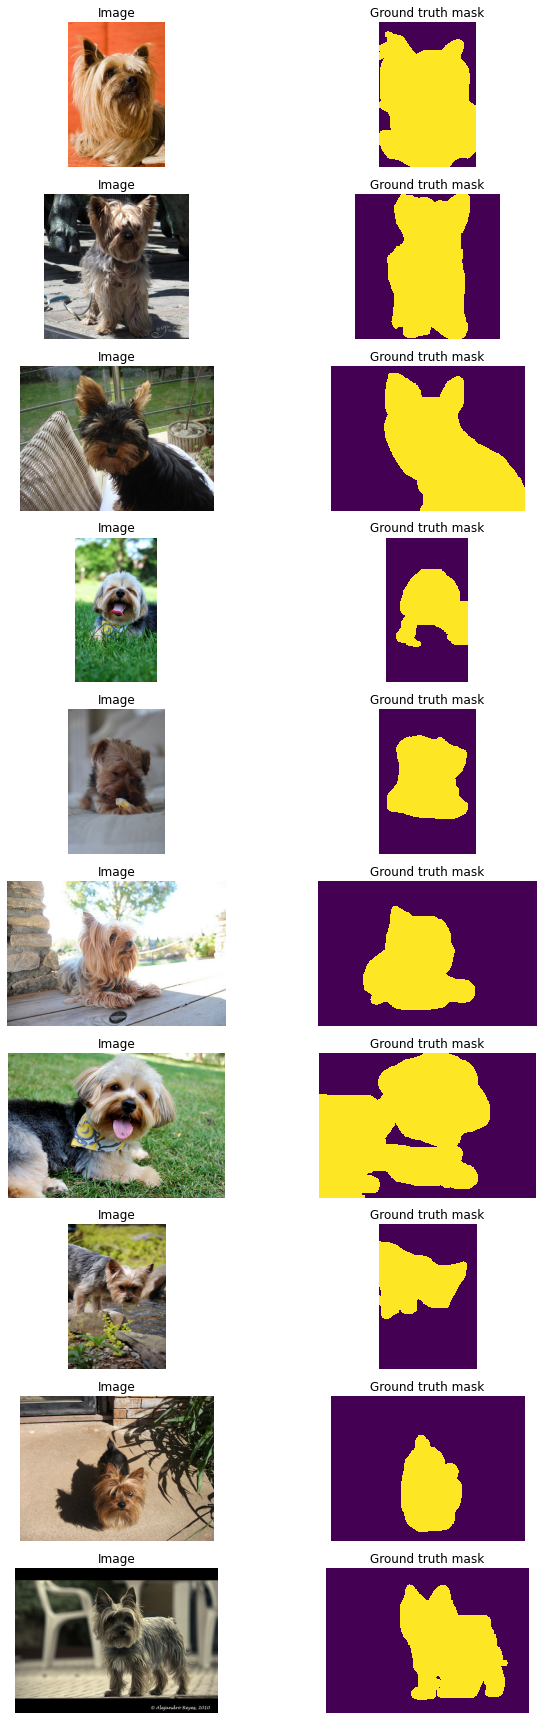

In [ ]:
display_image_grid(test_images_filenames, images_directory, masks_directory)

### Image sizes for training and prediction

Often, images that you use for training and inference have different heights and widths and different aspect ratios. That fact brings two challenges to a deep learning pipeline:
- PyTorch requires all images in a batch to have the same height and width.
- If a neural network is not fully convolutional, you have to use the same width and height for all images during training and inference. Fully convolutional architectures, such as UNet, can work with images of any size.

There are three common ways to deal with those challenges:
1. Resize all images and masks to a fixed size (e.g., 256x256 pixels) during training. After a model predicts a mask with that fixed size during inference, resize the mask to the original image size. This approach is simple, but it has a few drawbacks:
  - The predicted mask is smaller than the image, and the mask may lose some context and important details of the original image. 
  - This approach may be problematic if images in your dataset have different aspect ratios. For example, suppose you are resizing an image with the size 1024x512 pixels (so an image with an aspect ratio of 2:1) to 256x256 pixels (1:1 aspect ratio). In that case, this transformation will distort the image and may also affect the quality of predictions.
2. If you use a fully convolutional neural network, you can train a model with image crops, but use original images for inference. This option usually provides the best tradeoff between quality, speed of training, and hardware requirements.
3. Do not alter the sizes of images and use source images both for training and inference. With this approach, you won't lose any information. However, original images could be quite large, so they may require a lot of GPU memory. Also, this approach requires more training time to obtain good results.

Some architectures, such as UNet, require that an image's size must be divisible by a downsampling factor of a network (usually 32), so you may also need to pad an image with borders. Albumentations provides a particular transformation for that case.

The following example shows how different types of images look.

In [ ]:
example_image_filename = correct_images_filenames[0]
image = cv2.imread(os.path.join(images_directory, example_image_filename), cv2.IMREAD_COLOR_RGB)

resized_image = F.resize(image, height=256, width=256)
padded_image = F.pad(image, min_height=512, min_width=512)
padded_constant_image = F.pad(image, min_height=512, min_width=512, border_mode=cv2.BORDER_CONSTANT)
cropped_image = F.center_crop(image, crop_height=256, crop_width=256)

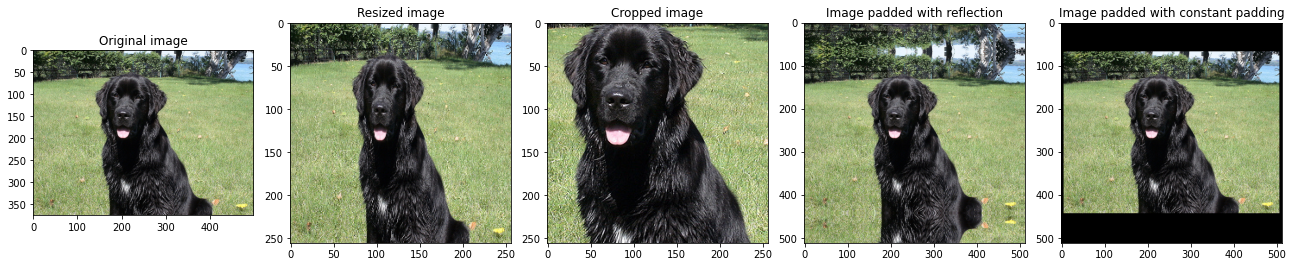

In [ ]:
figure, ax = plt.subplots(nrows=1, ncols=5, figsize=(18, 10))
ax.ravel()[0].imshow(image)
ax.ravel()[0].set_title("Original image")
ax.ravel()[1].imshow(resized_image)
ax.ravel()[1].set_title("Resized image")
ax.ravel()[2].imshow(cropped_image)
ax.ravel()[2].set_title("Cropped image")
ax.ravel()[3].imshow(padded_image)
ax.ravel()[3].set_title("Image padded with reflection")
ax.ravel()[4].imshow(padded_constant_image)
ax.ravel()[4].set_title("Image padded with constant padding")
plt.tight_layout()
plt.show()

In this tutorial, we will explore all three approaches for dealing with image sizes.

## Approach 1. Resize all images and masks to a fixed size (e.g., 256x256 pixels).

### Define a PyTorch dataset class

Next, we define a PyTorch dataset. If you are new to PyTorch datasets, please refer to this tutorial - https://pytorch.org/tutorials/beginner/data_loading_tutorial.html.

`__init__` will receive an optional `transform` argument. It is a transformation function of the Albumentations augmentation pipeline. Then in `__getitem__`, the Dataset class will use that function to augment an image and a mask and return their augmented versions.

In [ ]:
class OxfordPetDataset(Dataset):
    def __init__(self, images_filenames, images_directory, masks_directory, transform=None):
        self.images_filenames = images_filenames
        self.images_directory = images_directory
        self.masks_directory = masks_directory
        self.transform = transform

    def __len__(self):
        return len(self.images_filenames)

    def __getitem__(self, idx):
        image_filename = self.images_filenames[idx]
        image = cv2.imread(os.path.join(self.images_directory, image_filename))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(
            os.path.join(self.masks_directory, image_filename.replace(".jpg", ".png")),
            cv2.IMREAD_UNCHANGED,
        )
        mask = preprocess_mask(mask)
        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]
        return image, mask

Next, we create augmentation pipelines for the training and validation datasets. Note that we use `A.Resize(256, 256)` to resize input images and masks to the size 256x256 pixels.

In [ ]:
train_transform = A.Compose(
    [
        A.Resize(256, 256),
        A.ShiftScaleRotate(shift_limit=0.2, scale_limit=0.2, rotate_limit=30, p=0.5),
        A.RGBShift(r_shift_limit=25, g_shift_limit=25, b_shift_limit=25, p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ],
    strict=True,
    seed=137,
)
train_dataset = OxfordPetDataset(train_images_filenames, images_directory, masks_directory, transform=train_transform)

val_transform = A.Compose(
    [A.Resize(256, 256), A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2()],
    strict=True,
    seed=137,
)
val_dataset = OxfordPetDataset(val_images_filenames, images_directory, masks_directory, transform=val_transform)

Let's define a function that takes a dataset and visualizes different augmentations applied to the same image and the associated mask.

In [ ]:
def visualize_augmentations(dataset, idx=0, samples=5):
    dataset = copy.deepcopy(dataset)
    dataset.transform = A.Compose([t for t in dataset.transform if not isinstance(t, (A.Normalize, ToTensorV2))])
    _, ax = plt.subplots(nrows=samples, ncols=2, figsize=(10, 24))
    for i in range(samples):
        image, mask = dataset[idx]
        ax[i, 0].imshow(image)
        ax[i, 1].imshow(mask, interpolation="nearest")
        ax[i, 0].set_title("Augmented image")
        ax[i, 1].set_title("Augmented mask")
        ax[i, 0].set_axis_off()
        ax[i, 1].set_axis_off()
    plt.tight_layout()
    plt.show()

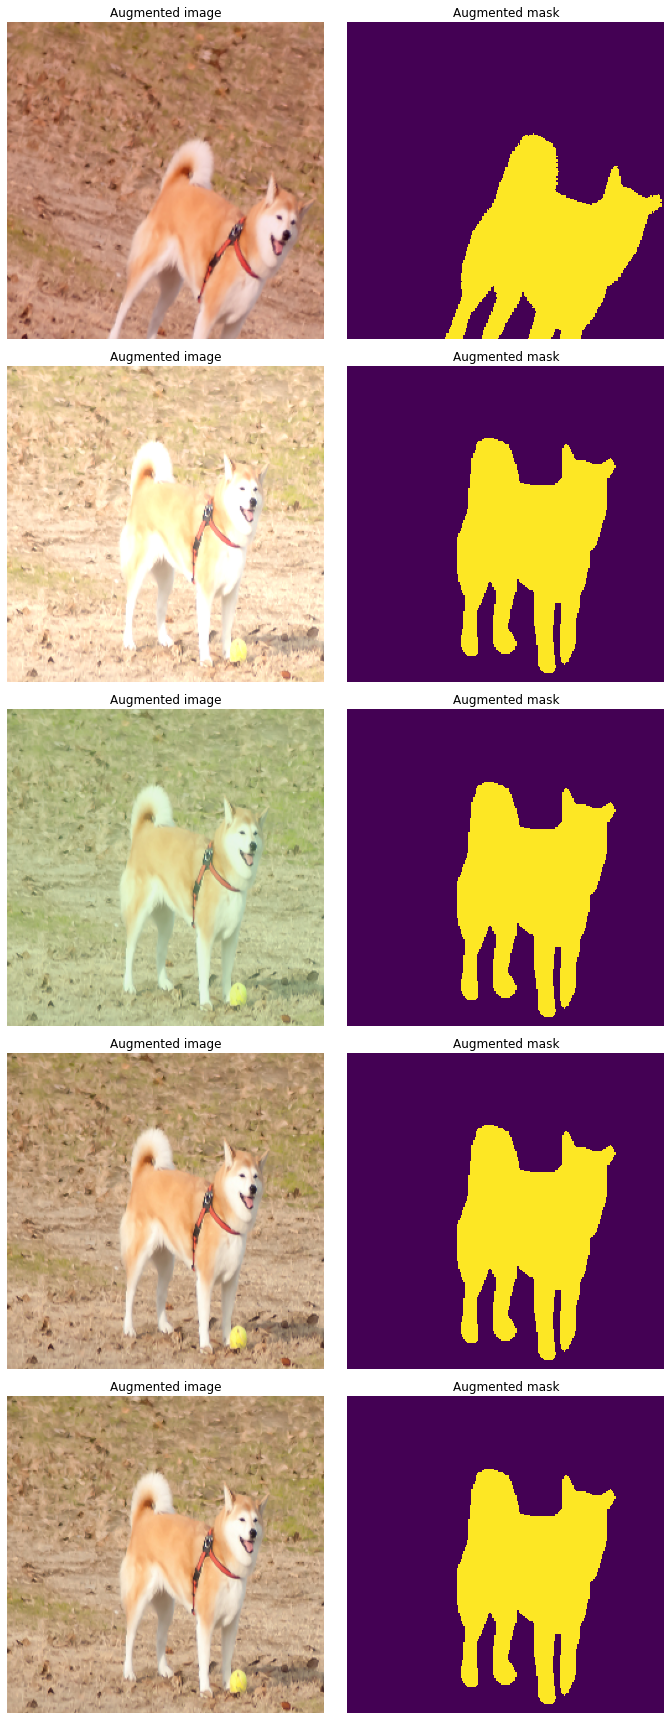

In [ ]:
random.seed(42)
visualize_augmentations(train_dataset, idx=55)

### Define helpers for training

`MetricMonitor` helps to track metrics such as accuracy or loss during training and validation.

In [ ]:
class MetricMonitor:
    def __init__(self, float_precision=3):
        self.float_precision = float_precision
        self.reset()

    def reset(self):
        self.metrics = defaultdict(lambda: {"val": 0, "count": 0, "avg": 0})

    def update(self, metric_name, val):
        metric = self.metrics[metric_name]

        metric["val"] += val
        metric["count"] += 1
        metric["avg"] = metric["val"] / metric["count"]

    def __str__(self):
        return " | ".join(
            [
                "{metric_name}: {avg:.{float_precision}f}".format(
                    metric_name=metric_name,
                    avg=metric["avg"],
                    float_precision=self.float_precision,
                )
                for (metric_name, metric) in self.metrics.items()
            ],
        )

### Define functions for training and validation

In [ ]:
def train(train_loader, model, criterion, optimizer, epoch, params):
    metric_monitor = MetricMonitor()
    model.train()
    stream = tqdm(train_loader)
    for _, (images, target) in enumerate(stream, start=1):
        images = images.to(params["device"], non_blocking=True)
        target = target.to(params["device"], non_blocking=True)
        output = model(images).squeeze(1)
        loss = criterion(output, target)
        metric_monitor.update("Loss", loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        stream.set_description(
            f"Epoch: {epoch}. Train.      {metric_monitor}",
        )

In [ ]:
def validate(val_loader, model, criterion, epoch, params):
    metric_monitor = MetricMonitor()
    model.eval()
    stream = tqdm(val_loader)
    with torch.no_grad():
        for _, (images, target) in enumerate(stream, start=1):
            images = images.to(params["device"], non_blocking=True)
            target = target.to(params["device"], non_blocking=True)
            output = model(images).squeeze(1)
            loss = criterion(output, target)
            metric_monitor.update("Loss", loss.item())
            stream.set_description(
                f"Epoch: {epoch}. Validation. {metric_monitor}",
            )

In [ ]:
def create_model(params):
    model = getattr(ternausnet.models, params["model"])(pretrained=True)
    return model.to(params["device"])

In [ ]:
def train_and_validate(model, train_dataset, val_dataset, params):
    train_loader = DataLoader(
        train_dataset,
        batch_size=params["batch_size"],
        shuffle=True,
        num_workers=params["num_workers"],
        pin_memory=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=params["batch_size"],
        shuffle=False,
        num_workers=params["num_workers"],
        pin_memory=True,
    )
    criterion = nn.BCEWithLogitsLoss().to(params["device"])
    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])
    for epoch in range(1, params["epochs"] + 1):
        train(train_loader, model, criterion, optimizer, epoch, params)
        validate(val_loader, model, criterion, epoch, params)
    return model

In [ ]:
def predict(model, params, test_dataset, batch_size):
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=params["num_workers"],
        pin_memory=True,
    )
    model.eval()
    predictions = []
    with torch.no_grad():
        for images, (original_heights, original_widths) in test_loader:
            images = images.to(params["device"], non_blocking=True)
            output = model(images)
            probabilities = torch.sigmoid(output.squeeze(1))
            predicted_masks = (probabilities >= 0.5).float() * 1
            predicted_masks = predicted_masks.cpu().numpy()
            for predicted_mask, original_height, original_width in zip(
                predicted_masks,
                original_heights.numpy(),
                original_widths.numpy(),
            ):
                predictions.append((predicted_mask, original_height, original_width))
    return predictions

### Define training parameters 

Here we define a few training parameters such as model architecture, learning rate, batch size, epochs, etc.

In [ ]:
params = {
    "model": "UNet11",
    "device": "cuda",
    "lr": 0.001,
    "batch_size": 16,
    "num_workers": 4,
    "epochs": 10,
}

### Train a model

In [ ]:
model = create_model(params)
model = train_and_validate(model, train_dataset, val_dataset, params)

Epoch: 10. Validation. Loss: 0.140: 100%|██████████| 86/86 [00:08<00:00, 10.60it/s]


### Predict labels for images and visualize those predictions

Now we have a trained model, so let's try to predict masks for some images. Note that the `__getitem__` method returns not only an image but also the original height and width of an image. We will use those values to resize a predicted mask from the size of 256x256 pixels to the original image's size.

In [ ]:
class OxfordPetInferenceDataset(Dataset):
    def __init__(self, images_filenames, images_directory, transform=None):
        self.images_filenames = images_filenames
        self.images_directory = images_directory
        self.transform = transform

    def __len__(self):
        return len(self.images_filenames)

    def __getitem__(self, idx):
        image_filename = self.images_filenames[idx]
        image = cv2.imread(os.path.join(self.images_directory, image_filename))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        original_size = tuple(image.shape[:2])
        if self.transform is not None:
            transformed = self.transform(image=image)
            image = transformed["image"]
        return image, original_size

In [ ]:
test_transform = A.Compose(
    [A.Resize(256, 256), A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2()],
    strict=True,
    seed=137,
)
test_dataset = OxfordPetInferenceDataset(test_images_filenames, images_directory, transform=test_transform)

In [ ]:
predictions = predict(model, params, test_dataset, batch_size=16)

Next, we will resize the predicted masks with the size of 256x256 pixels to the original images' size.

In [ ]:
predicted_masks = []
for predicted_256x256_mask, original_height, original_width in predictions:
    full_sized_mask = F.resize(
        predicted_256x256_mask,
        height=original_height,
        width=original_width,
        interpolation=cv2.INTER_NEAREST,
    )
    predicted_masks.append(full_sized_mask)

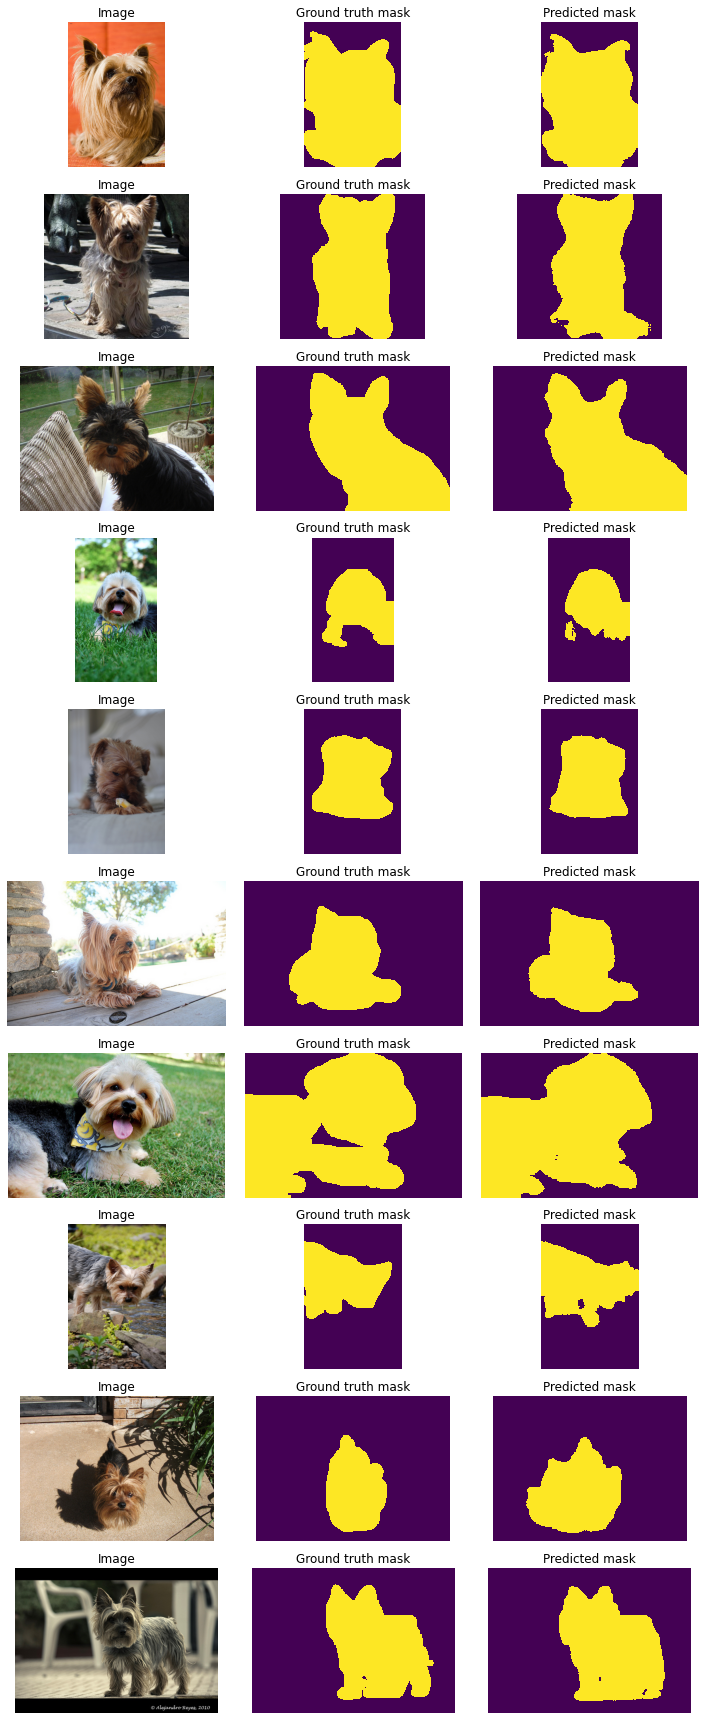

In [ ]:
display_image_grid(test_images_filenames, images_directory, masks_directory, predicted_masks=predicted_masks)

## Approach 2. Train on crops, predict masks for full-sized images

We will reuse most of the code from the previous example.

Heights and widths of the same images in the dataset are less than the crop size (256x256 pixels), so we first apply `A.PadIfNeeded(min_height=256, min_width=256)` which will pad an image if its height or width is less than 256 pixels.

In [ ]:
train_transform = A.Compose(
    [
        A.PadIfNeeded(min_height=256, min_width=256),
        A.RandomCrop(256, 256),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ],
    strict=True,
    seed=137,
)
train_dataset = OxfordPetDataset(train_images_filenames, images_directory, masks_directory, transform=train_transform)

In [ ]:
val_transform = A.Compose(
    [
        A.PadIfNeeded(min_height=256, min_width=256),
        A.CenterCrop(256, 256),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ],
    strict=True,
    seed=137,
)
val_dataset = OxfordPetDataset(val_images_filenames, images_directory, masks_directory, transform=val_transform)

In [ ]:
params = {
    "model": "UNet11",
    "device": "cuda",
    "lr": 0.001,
    "batch_size": 16,
    "num_workers": 4,
    "epochs": 10,
}

In [ ]:
model = create_model(params)
model = train_and_validate(model, train_dataset, val_dataset, params)

Epoch: 10. Validation. Loss: 0.159: 100%|██████████| 86/86 [00:08<00:00, 10.49it/s]


All images in the test dataset have a max side with size 500 pixels. Since PyTorch requires that all images in a batch must have the same dimensions, and also UNet requires that the size of an image will be divisible by 16, we will apply `A.PadIfNeeded(min_height=512, min_width=512, border_mode=cv2.BORDER_CONSTANT)`. That augmentation will pad image borders with zeros so the image size will become 512x512 pixels.

In [ ]:
test_transform = A.Compose(
    [
        A.PadIfNeeded(min_height=512, min_width=512, border_mode=cv2.BORDER_CONSTANT),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ],
)
test_dataset = OxfordPetInferenceDataset(test_images_filenames, images_directory, transform=test_transform)

In [ ]:
predictions = predict(model, params, test_dataset, batch_size=16)

Since we received masks for padded images, we need to crop a part of the original image size from the padded mask.


In [ ]:
predicted_masks = []
for predicted_padded_mask, original_height, original_width in predictions:
    cropped_mask = F.center_crop(predicted_padded_mask, original_height, original_width)
    predicted_masks.append(cropped_mask)

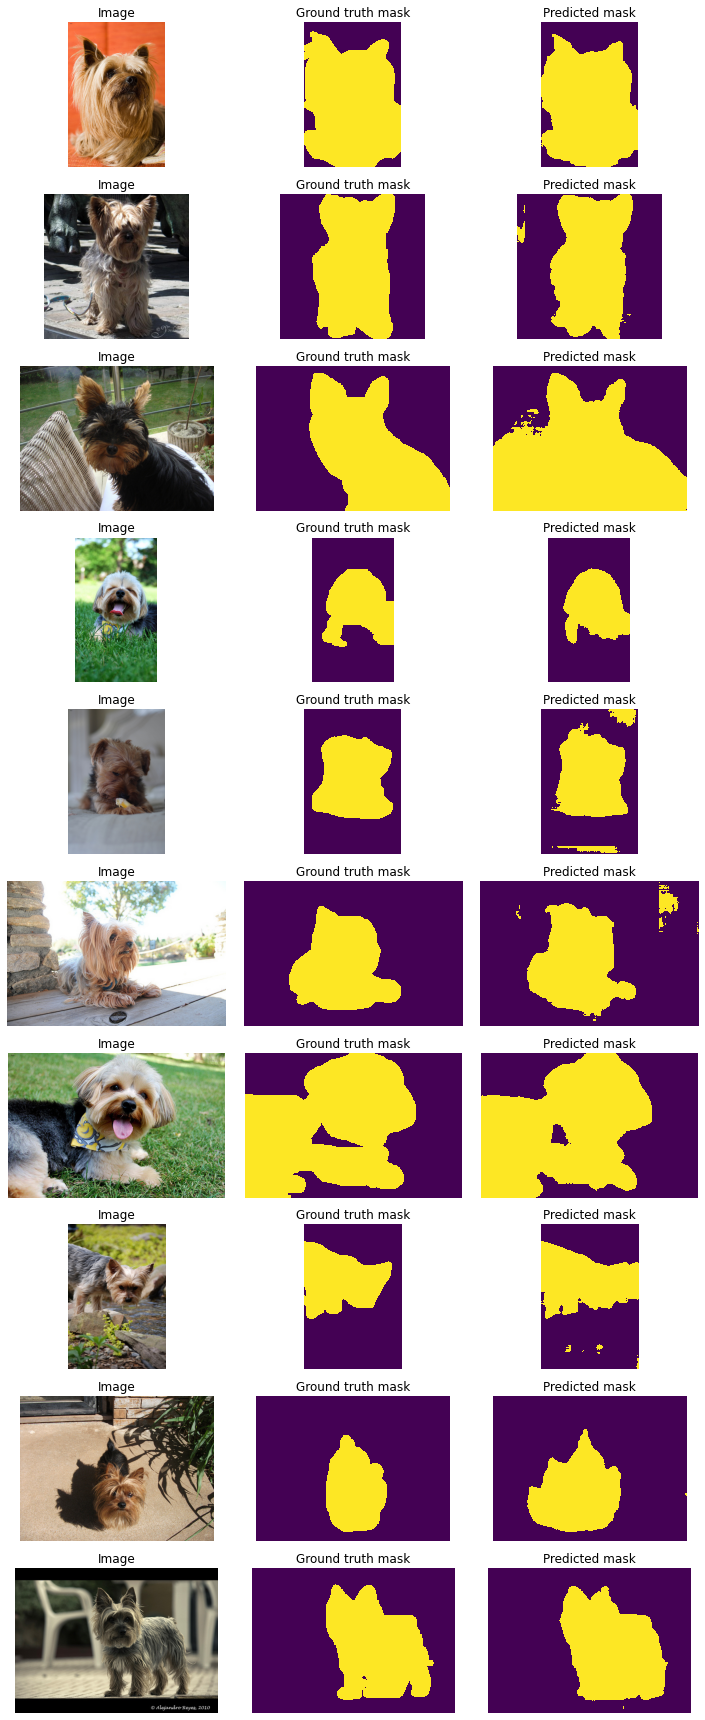

In [ ]:
display_image_grid(test_images_filenames, images_directory, masks_directory, predicted_masks=predicted_masks)

## Approach 3. Use original images.

We could also use original images without resizing or cropping them. However, there is a problem with this dataset. A few images in the dataset are so large that even with `batch_size=1`, they require more than 11Gb of GPU memory for training. So as a tradeoff, we will first apply the `A.LongestMaxSize(512)` augmentation that will ensure that an image's largest size is no more than 512 pixels. That augmentation will affect only 137 out of 7384 dataset images.

Next will use `A.PadIfNeeded(min_height=512, min_width=512)` to ensure that all images in a batch will have size 512x512 pixels.

In [ ]:
train_transform = A.Compose(
    [
        A.LongestMaxSize(512),
        A.PadIfNeeded(min_height=512, min_width=512),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ],
    strict=True,
    seed=137,
)
train_dataset = OxfordPetDataset(train_images_filenames, images_directory, masks_directory, transform=train_transform)

val_transform = A.Compose(
    [
        A.LongestMaxSize(512),
        A.PadIfNeeded(min_height=512, min_width=512, border_mode=cv2.BORDER_CONSTANT),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ],
    strict=True,
    seed=137,
)
val_dataset = OxfordPetDataset(val_images_filenames, images_directory, masks_directory, transform=val_transform)

In [ ]:
params = {
    "model": "UNet11",
    "device": "cuda",
    "lr": 0.001,
    "batch_size": 8,
    "num_workers": 4,
    "epochs": 10,
}

In [ ]:
model = create_model(params)
model = train_and_validate(model, train_dataset, val_dataset, params)

Epoch: 10. Validation. Loss: 0.115: 100%|██████████| 172/172 [00:34<00:00,  4.97it/s]


Next, we will use the same code that we were using in Approach 2 to make predictions.

In [ ]:
test_transform = A.Compose(
    [
        A.PadIfNeeded(min_height=512, min_width=512, border_mode=cv2.BORDER_CONSTANT),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ],
)
test_dataset = OxfordPetInferenceDataset(test_images_filenames, images_directory, transform=test_transform)

In [ ]:
predictions = predict(model, params, test_dataset, batch_size=16)

In [ ]:
predicted_masks = []
for predicted_padded_mask, original_height, original_width in predictions:
    cropped_mask = F.center_crop(predicted_padded_mask, original_height, original_width)
    predicted_masks.append(cropped_mask)

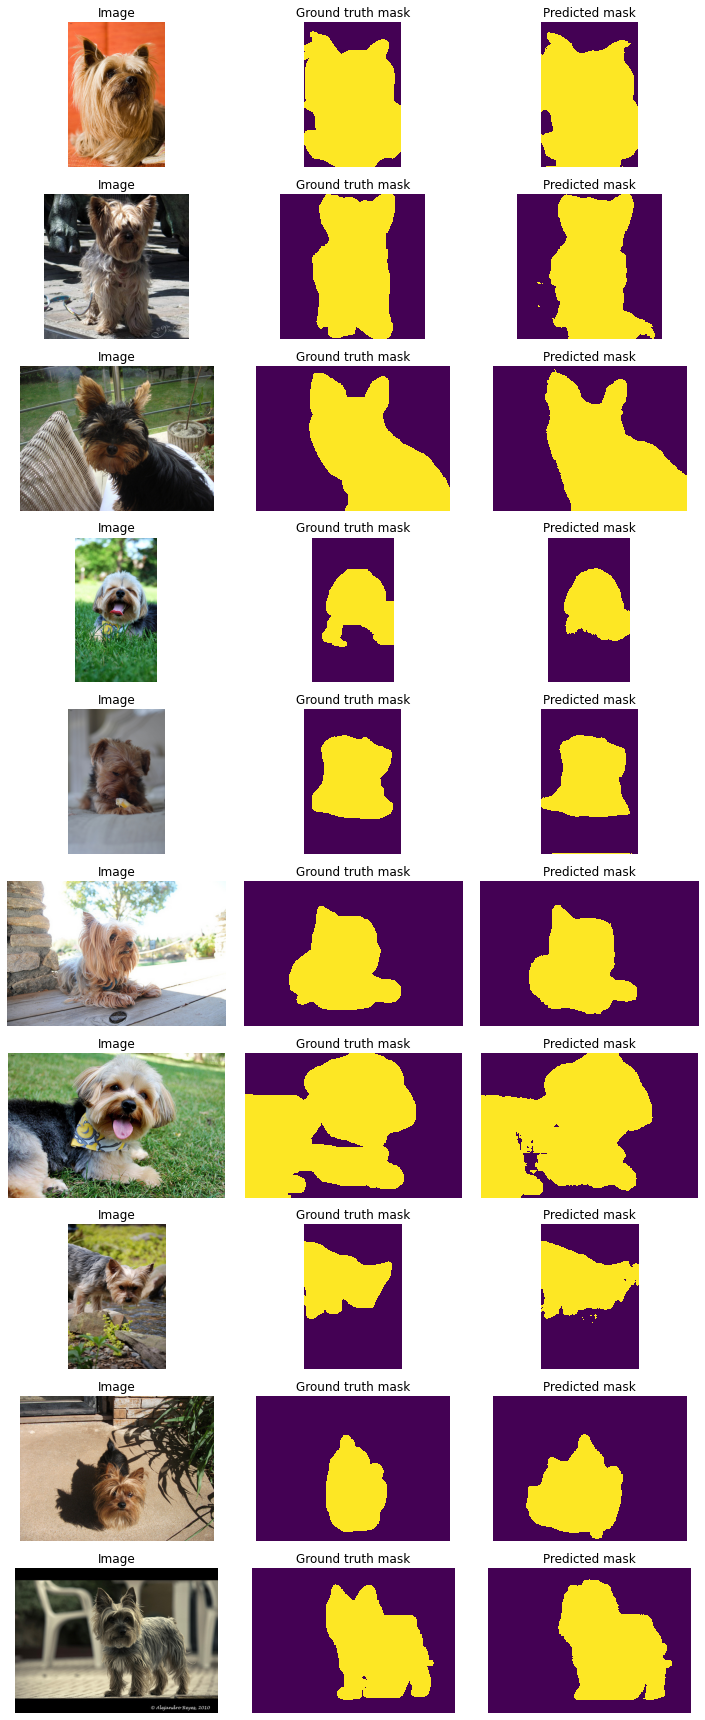

In [ ]:
display_image_grid(test_images_filenames, images_directory, masks_directory, predicted_masks=predicted_masks)